<a href="https://colab.research.google.com/github/sahilsagarprasad97-spec/FLYRANK-AI/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
import os
import sys
import subprocess
import json
import pandas as pd
import numpy as np

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(
            ["git", "clone", "--depth", "1", REPO_URL, REPO_DIR],
            check=True
        )

    os.chdir(REPO_DIR)

    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "-r",
            "requirements.txt"
        ],
        check=True
    )
else:
    while not os.path.isdir("data/raw") and os.getcwd() != "/":
        os.chdir("..")

print("Working directory:", os.getcwd())

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print("Output folders ready.")

Working directory: /content/flyrank-ml-internship-starter
Output folders ready.


## 1. Question

*The research question and the decision it supports.*

### Research question

Can observable search-visibility and engagement signals be combined into a readable model that helps prioritize anonymized content items for human review?

### Decision supported

The analysis is designed to help a content or SEO analyst decide which pages deserve review first.

The model is a directional decision-support signal. It does not automatically decide which pages should be changed, refreshed, deleted, redirected, or published.

### Scope

The analysis uses an anonymized warehouse slice and evaluates whether a grouped-by-client model can rank observed engagement outcomes on clients that were not used for training.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

### Dataset

This project uses the FlyRank Internship Warehouse release described in the public dataset documentation.

The warehouse contains anonymized, pseudonymized content-performance observations. The analysis does not attempt to identify clients, domains, URLs, or individual people.

### Table used

The main analytical table is:

`fact_content_daily_performance`

The unit of analysis is one observed report date × pseudonymized client × pseudonymized content item.

### Development window

The modeling work uses March 2026:

`2026-03-01` through `2026-03-31`

This window is treated as a development slice rather than as a universal representation of all content performance.

### Fields used

Model features:

- `gsc_impressions`
- `gsc_clicks`
- `gsc_sum_position`
- `sessions_organic`

Observed target:

- `scroll_events`

Context/grouping fields:

- `report_date`
- `client_hash_id`
- `content_hash_id`

### Excluded

I excluded:

- client-identifying information;
- content-identifying information from the model features;
- outcome-derived trend fields;
- future outcome information;
- decision/product flags;
- fields that would only be known after the outcome.

The identifiers are used only for grouping and validation, not as predictive features.

### Data availability

GSC and GA4 availability can differ across clients and dates. Missing source data is therefore not automatically interpreted as zero performance.

In [2]:
import duckdb

from google.colab import userdata

HF_TOKEN = userdata.get("HF_TOKEN")

if not HF_TOKEN:
    raise ValueError(
        "HF_TOKEN was not found. Add your Hugging Face READ token "
        "as a Colab Secret named HF_TOKEN."
    )

print("HF_TOKEN found.")

con = duckdb.connect()

con.execute(
    "CREATE SECRET (TYPE huggingface, TOKEN ?)",
    [HF_TOKEN]
)

march_df = con.sql("""
    SELECT
        report_date,
        client_hash_id,
        content_hash_id,
        client_has_gsc,
        client_has_ga4,
        gsc_data_available,
        ga4_data_available,
        gsc_impressions,
        gsc_clicks,
        gsc_sum_position,
        scroll_events,
        sessions_ai,
        sessions_paid,
        sessions_direct,
        sessions_social,
        sessions_organic,
        month
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet'
    )
    WHERE month = '2026-03'
""").df()

print("March 2026 shape:", march_df.shape)

print(
    "Date range:",
    march_df["report_date"].min(),
    "to",
    march_df["report_date"].max()
)

print(
    "Unique clients:",
    march_df["client_hash_id"].nunique()
)

print(
    "Unique content items:",
    march_df["content_hash_id"].nunique()
)

display(march_df.head())

HF_TOKEN found.


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

March 2026 shape: (9841378, 17)
Date range: 2026-03-01 00:00:00 to 2026-03-31 00:00:00
Unique clients: 55
Unique content items: 331437


,report_date,client_hash_id,content_hash_id,client_has_gsc,client_has_ga4,gsc_data_available,ga4_data_available,gsc_impressions,gsc_clicks,gsc_sum_position,scroll_events,sessions_ai,sessions_paid,sessions_direct,sessions_social,sessions_organic,month
0,2026-03-01,client_73cda7b4e4f265ea,content_b7e512995f79d5a6,True,False,True,<NA>,20,0,67,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
1,2026-03-01,client_73cda7b4e4f265ea,content_05597932fe4da067,True,False,True,<NA>,1,0,0,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
2,2026-03-01,client_73cda7b4e4f265ea,content_7a105f548d9c6916,True,False,True,<NA>,125,1,616,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
3,2026-03-01,client_73cda7b4e4f265ea,content_905aa32a0230694e,True,False,True,<NA>,7,0,28,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03
4,2026-03-01,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,True,False,True,<NA>,11,0,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2026-03


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

### Model

I use a Random Forest regression model to estimate observed `scroll_events`.

The model was chosen because the relationship between search visibility, position, clicks, organic sessions, and engagement may be nonlinear. The model is used for ranking/decision support rather than causal inference.

### Features

The model uses four observable features:

1. GSC impressions
2. GSC clicks
3. GSC summed position
4. Organic sessions

### Target

The target is observed `scroll_events`.

This is treated as an engagement proxy. It is not a measure of content quality and is not evidence that any content change caused the observed outcome.

### Baseline

The Week-4 baseline combines:

- impression rank: 40%
- click rank: 40%
- position rank: 20%

Higher baseline score means higher review priority.

### Validation

The primary validation uses a grouped-by-client split.

Entire clients are held out from training so that pages from the same client do not appear in both training and test sets.

This is preferred to a random row-level split because the warehouse contains repeated observations from the same clients.

### Evaluation metric

The primary comparison metric is Spearman rank correlation between the ranking score and observed `scroll_events`.

This matches the decision-support purpose: the question is whether the method provides a useful ordering of content items.

### Leakage checks

I checked the final feature set for:

- trend-derived fields;
- target/label fields;
- future outcome fields;
- client/content identifiers;
- decision/action flags.

No such fields are used as model inputs.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestRegressor
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error

model_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_sum_position",
    "sessions_organic",
    "scroll_events"
]

model_df = march_df[
    [
        "report_date",
        "client_hash_id",
        "content_hash_id"
    ] + model_cols
].copy()

for col in model_cols:
    model_df[col] = pd.to_numeric(
        model_df[col],
        errors="coerce"
    )

model_df = model_df.dropna(
    subset=[
        "gsc_impressions",
        "gsc_clicks",
        "gsc_sum_position",
        "scroll_events"
    ]
).copy()

feature_cols = [
    "gsc_impressions",
    "gsc_clicks",
    "gsc_sum_position",
    "sessions_organic"
]

X = model_df[feature_cols].copy()
y = model_df["scroll_events"].copy()
groups = model_df["client_hash_id"].copy()

print("Usable modeling rows:", len(model_df))
print("Unique clients:", groups.nunique())
print("Features:", feature_cols)

Usable modeling rows: 6822637
Unique clients: 43
Features: ['gsc_impressions', 'gsc_clicks', 'gsc_sum_position', 'sessions_organic']


In [4]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(
        X,
        y,
        groups=groups
    )
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]

y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

model = RandomForestRegressor(
    n_estimators=150,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

model.fit(
    X_train,
    y_train
)

model_pred = model.predict(X_test)

model_spearman = spearmanr(
    y_test,
    model_pred
).statistic

model_mae = mean_absolute_error(
    y_test,
    model_pred
)

model_rmse = root_mean_squared_error(
    y_test,
    model_pred)

print("Grouped-client validation")
print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", groups_train.nunique())
print("Test clients:", groups_test.nunique())
print("Spearman:", round(model_spearman, 4))
print("MAE:", round(model_mae, 4))
print("Random Forest RMSE:", model_rmse)

Grouped-client validation
Train rows: 4879304
Test rows: 1943333
Train clients: 34
Test clients: 9
Spearman: 0.2759
MAE: 0.0817
Random Forest RMSE: 0.5400442125262545


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [5]:
test_baseline = model_df.iloc[test_idx].copy()

test_baseline["impression_rank"] = (
    test_baseline["gsc_impressions"]
    .rank(pct=True)
)

test_baseline["click_rank"] = (
    test_baseline["gsc_clicks"]
    .rank(pct=True)
)

test_baseline["position_rank"] = (
    1 -
    test_baseline["gsc_sum_position"]
    .rank(pct=True)
)

test_baseline["baseline_score"] = (
    0.40 * test_baseline["impression_rank"]
    + 0.40 * test_baseline["click_rank"]
    + 0.20 * test_baseline["position_rank"]
)

baseline_spearman = spearmanr(
    test_baseline["scroll_events"],
    test_baseline["baseline_score"]
).statistic

comparison = pd.DataFrame({
    "method": [
        "Week-4 baseline",
        "Random Forest"
    ],
    "Spearman": [
        baseline_spearman,
        model_spearman
    ],
    "MAE": [
        np.nan,
        model_mae
    ],
    "RMSE": [
        np.nan,
        model_rmse
    ]
})

display(comparison)

,method,Spearman,MAE,RMSE
0,Week-4 baseline,0.257703,NaN,NaN
1,Random Forest,0.275906,0.081652,0.540044


### Results interpretation

The model and baseline are compared on exactly the same held-out client groups.

The Spearman result measures ranking agreement with observed `scroll_events`. A higher value means stronger rank association on this particular held-out slice.

The result should therefore be described as a measured validation result for this dataset and split, not as proof of universal model superiority.

If the Random Forest score is higher than the baseline, the appropriate statement is that it showed stronger measured rank association on this validation split.

If the baseline is higher, the appropriate statement is that the simple baseline performed better on this validation split.

Neither result establishes causality.

In [6]:
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

display(importance_df)

,feature,importance
0,sessions_organic,0.814310
1,gsc_impressions,0.088140
2,gsc_sum_position,0.080506
3,gsc_clicks,0.017044


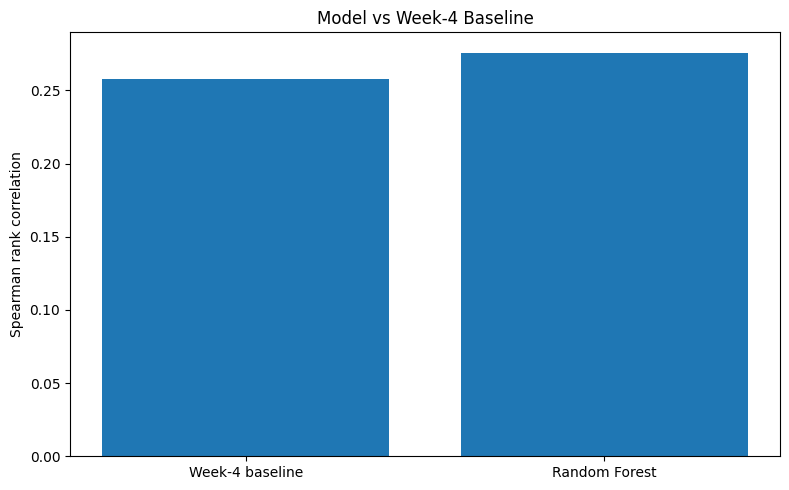

Saved: work/figures/model_vs_baseline_spearman.png


In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["method"],
    comparison["Spearman"]
)

plt.ylabel("Spearman rank correlation")
plt.title("Model vs Week-4 Baseline")

plt.tight_layout()

results_figure = "work/figures/model_vs_baseline_spearman.png"

plt.savefig(
    results_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", results_figure)

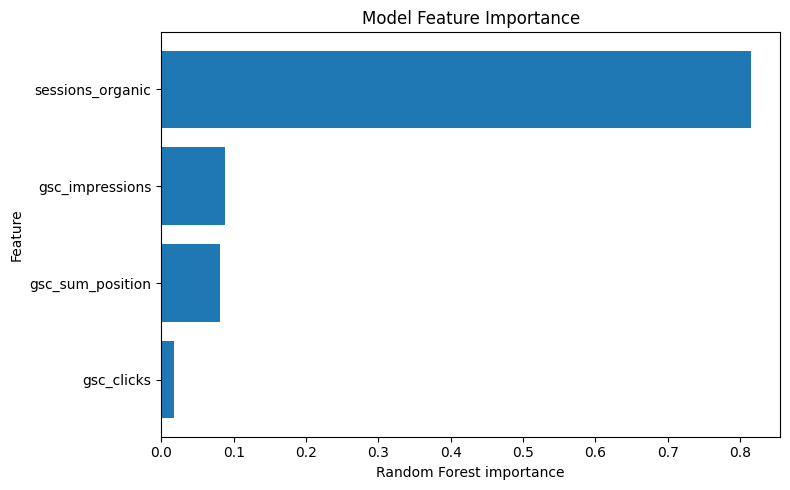

Saved: work/figures/model_feature_importance.png


In [8]:
plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.xlabel("Random Forest importance")
plt.ylabel("Feature")
plt.title("Model Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()

importance_figure = "work/figures/model_feature_importance.png"

plt.savefig(
    importance_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Saved:", importance_figure)

## 5. Limitations

*What this work cannot claim.*

This analysis has several important limits.

### 1. One development window

The model is developed on March 2026 data. Performance may differ in another month or under another traffic environment.

### 2. Observational data

The analysis is observational. It does not establish that a content refresh, title change, or other intervention caused an improvement.

### 3. Engagement proxy

`scroll_events` is an observed engagement signal. It is not a direct measure of content quality, business value, revenue, or user satisfaction.

### 4. Generalization

Grouped-by-client validation reduces repeated-client leakage risk, but the result is still based on a finite sample of clients and one time window.

### 5. Missing source data

GSC and GA4 availability varies. Missing values can represent unavailable source data rather than zero activity.

### 6. Ranking rather than causal decision

The model provides a ranking signal for human review. It does not determine which pages should be changed.

### 7. No automatic action

The output should not automatically publish, delete, redirect, rewrite, or otherwise modify content.

### 8. Anonymization

The underlying warehouse is pseudonymized/anonymized. This paper intentionally does not expose client names, domains, URLs, private queries, or other identifying information.

### Honest framing

The strongest defensible claim is:

> The model provides a measured, directional ranking signal for prioritizing anonymized content items for human review on the evaluated data slice.

It is not evidence that the model will cause traffic, clicks, rankings, or engagement to increase.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [9]:
# Build the action queue from the held-out predictions.

recommendations = model_df.iloc[test_idx].copy()

recommendations["predicted_scroll_events"] = model_pred

recommendations["engagement_opportunity"] = (
    1 -
    recommendations["predicted_scroll_events"]
    .rank(pct=True)
)

recommendations["impression_rank"] = (
    recommendations["gsc_impressions"]
    .rank(pct=True)
)

recommendations["position_rank"] = (
    1 -
    recommendations["gsc_sum_position"]
    .rank(pct=True)
)

recommendations["action_score"] = (
    0.50 * recommendations["engagement_opportunity"]
    + 0.30 * recommendations["impression_rank"]
    + 0.20 * recommendations["position_rank"]
)

impression_cutoff = (
    recommendations["gsc_impressions"]
    .quantile(0.75)
)

position_cutoff = (
    recommendations["gsc_sum_position"]
    .quantile(0.75)
)

opportunity_cutoff = (
    recommendations["engagement_opportunity"]
    .quantile(0.75)
)

recommendations["reason_code"] = np.select(
    [
        (
            (recommendations["gsc_impressions"] >= impression_cutoff)
            &
            (
                recommendations["engagement_opportunity"]
                >= opportunity_cutoff
            )
        ),
        (
            recommendations["gsc_sum_position"]
            >= position_cutoff
        )
    ],
    [
        "HIGH_VISIBILITY_LOW_ENGAGEMENT",
        "POSITION_REVIEW"
    ],
    default="MIXED_SIGNAL_REVIEW"
)

recommendations["action"] = "Human review"

recommendations = recommendations.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

recommendations["rank"] = (
    np.arange(1, len(recommendations) + 1)
)

recommendation_cols = [
    "rank",
    "report_date",
    "content_hash_id",
    "action_score",
    "reason_code",
    "action",
    "predicted_scroll_events",
    "gsc_impressions",
    "gsc_clicks",
    "gsc_sum_position",
    "sessions_organic"
]

ranked_recommendations = recommendations[
    recommendation_cols
].copy()

display(
    ranked_recommendations.head(20)
)

,rank,report_date,content_hash_id,action_score,reason_code,action,predicted_scroll_events,gsc_impressions,gsc_clicks,gsc_sum_position,sessions_organic
0,1,2026-03-14,content_85fbeb8bf5fbb90e,0.586471,MIXED_SIGNAL_REVIEW,Human review,0.013856,255,0,0,0
1,2,2026-03-04,content_7888373b5884ed2b,0.583450,MIXED_SIGNAL_REVIEW,Human review,0.013856,208,0,0,0
2,3,2026-03-15,content_85fbeb8bf5fbb90e,0.582744,MIXED_SIGNAL_REVIEW,Human review,0.013856,199,0,0,0
3,4,2026-03-30,content_c595149977a96d84,0.582202,MIXED_SIGNAL_REVIEW,Human review,0.014178,201,1,0,0
4,5,2026-03-08,content_a13c0af1132f0581,0.574345,MIXED_SIGNAL_REVIEW,Human review,0.015151,142,0,0,0
5,6,2026-03-15,content_007c73f1f29fb2ef,0.573610,MIXED_SIGNAL_REVIEW,Human review,0.015228,139,0,0,0
6,7,2026-03-17,content_ad51e400b57b772c,0.573316,MIXED_SIGNAL_REVIEW,Human review,0.015228,137,0,0,0
7,8,2026-03-09,content_1ca179a517fc24e6,0.573141,MIXED_SIGNAL_REVIEW,Human review,0.015158,134,0,0,0
8,9,2026-03-10,content_3d7b7011738d682f,0.573125,MIXED_SIGNAL_REVIEW,Human review,0.014944,131,0,0,0
9,10,2026-03-13,content_f9e04ee043a37ad6,0.572792,MIXED_SIGNAL_REVIEW,Human review,0.014742,127,0,0,0


### Recommendations

The ranked queue is a human-review prioritization list.

#### Priority 1 — High visibility + low predicted engagement

Review pages that have substantial search visibility but relatively weak model-estimated engagement.

A reviewer should inspect search intent, title/snippet alignment, page opening, content clarity, and user experience before deciding whether any change is justified.

#### Priority 2 — Position review

Pages with comparatively weaker position signals can be reviewed for relevance, topical coverage, internal linking, and content completeness.

#### Priority 3 — Mixed-signal review

Items where signals do not point to one clear issue should receive lower-confidence manual review rather than an automatic intervention.

### Human-review rule

No recommendation should directly trigger publication, deletion, rewriting, redirecting, or indexing changes.

The queue identifies what to inspect; a human decides what, if anything, should change.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

In [10]:
# Save the ranked queue.
queue_path = "work/outputs/capstone_ranked_recommendations.csv"

ranked_recommendations.to_csv(
    queue_path,
    index=False
)

print("Saved queue:", queue_path)

# Save metrics receipt.
metrics_receipt = {
    "data_window": "2026-03",
    "target": "scroll_events",
    "features": feature_cols,
    "validation": "grouped_by_client",
    "random_state": 42,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "train_clients": int(groups_train.nunique()),
    "test_clients": int(groups_test.nunique()),
    "baseline_spearman": float(baseline_spearman),
    "model_spearman": float(model_spearman),
    "model_mae": float(model_mae),
    "queue_rows": int(len(ranked_recommendations))
}

metrics_path = "work/outputs/capstone_metrics.json"

with open(metrics_path, "w") as f:
    json.dump(
        metrics_receipt,
        f,
        indent=2
    )

print("Saved metrics:", metrics_path)

display(
    pd.DataFrame([metrics_receipt])
)

Saved queue: work/outputs/capstone_ranked_recommendations.csv
Saved metrics: work/outputs/capstone_metrics.json


,data_window,target,features,validation,random_state,train_rows,test_rows,train_clients,test_clients,baseline_spearman,model_spearman,model_mae,queue_rows
0,2026-03,scroll_events,"[gsc_impressions, gsc_clicks, gsc_sum_position...",grouped_by_client,42,4879304,1943333,34,9,0.257703,0.275906,0.081652,1943333


In [11]:
artifacts = [
    results_figure,
    importance_figure,
    queue_path,
    metrics_path
]

artifact_check = pd.DataFrame({
    "artifact": artifacts,
    "exists": [
        os.path.exists(path)
        for path in artifacts
    ]
})

display(artifact_check)

,artifact,exists
0,work/figures/model_vs_baseline_spearman.png,True
1,work/figures/model_feature_importance.png,True
2,work/outputs/capstone_ranked_recommendations.csv,True
3,work/outputs/capstone_metrics.json,True


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
